# Deep Hedging AI
### Vanilla Deep Hedging engine reference implementation with dynamic training update.

This is the main example notebook. It shows learning to hedge a vanilla call option (ATM by default), first in a Black & Scholes world with statistical drift, and secondly in a world where a second option can be traded.
The examples are not intended to be overly realistic.

In the Black & Scholes case we see that the hedge learned is _not_ the risk-neutral hedge. The notebook <tt>trainer-bs_nodrift.ipynb</tt> demonstrates that if the statistical drift is zero, and step size is sufficiently small (daily), then the Deep Hedging hedge approximates the risk-neutral hedge.

### Hans Buehler, June 30 2022


In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import tensorflow as tf

/Users/bartkoedijk/Bestanden/Thesis Code/deephedging/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
""" Slighly annoying: by default the SageMaker Python import directory does not include our git directory """
#!pip -q install cdxbasics "tensorflow>=2.11" "tensorflow_probability==0.19"
import os
p = os.getcwd()
dhn = "/deephedging/"
i = p.find(dhn)
my_path = None
if i!=-1:
    my_path = p[:i]
    import sys
    sys.path.append(my_path)
    print("SageMaker: added python path %s" % my_path)
else:
    print(sys.path)

SageMaker: added python path /Users/bartkoedijk/Bestanden/Thesis Code


In [3]:
import sys
import os

# This gets the path to the directory ABOVE 'deephedging'
# so that 'import deephedging.trainer' works correctly
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../..'))

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [4]:
from cdxbasics.config import Config
from deephedging.trainer import train
from deephedging.gym import VanillaDeepHedgingGym
from deephedging.world import PPAWorld
from deephedging.objectives import oce_utility

from IPython.display import display, Markdown
from cdxbasics.config import Config

import numpy as np
from scipy.stats import skew
from scipy.optimize import minimize_scalar

Tensorflow version 2.16.2 running on 1 CPUs and 0 GPUs


In [ ]:
from cdxbasics.config import Config
import numpy as np
import matplotlib.pyplot as plt

# Simuleer zonder congestie om de uncapped verdeling te zien
calib_cfg = Config()
calib_cfg.samples = 100000
calib_cfg.steps = 48
calib_cfg.latent_model_type = 'synthetic'
calib_cfg.l_max = 999999999  # effectief oneindig

calib_world = PPAWorld(calib_cfg)

q_realized = calib_world.details.site_realized   # (nSamples, num_dim)
num_dim = q_realized.shape[1]

# Zelfde formule als in world.py
capacity = 1.0
installed_cap_per_site = np.full(num_dim, capacity / num_dim)
mwh = q_realized * installed_cap_per_site        # (nSamples, num_dim)
q_cong = mwh[:, :num_dim // 2].sum(axis=1)       # (nSamples,)

p70 = np.percentile(q_cong, 70)
p75 = np.percentile(q_cong, 75)
print(f"70e percentiel q_cong: {p70:.4f}")
print(f"75e percentiel q_cong: {p75:.4f}")
print(f"Fractie boven p70: {np.mean(q_cong > p70):.3f}")

plt.figure(figsize=(8, 4))
plt.hist(q_cong, bins=100, density=True, alpha=0.7, label='q_cong')
plt.axvline(p70, color='red',    linestyle='--', label=f'70e pct = {p70:.4f}')
plt.axvline(p75, color='orange', linestyle='--', label=f'75e pct = {p75:.4f}')
plt.xlabel('q_cong (som gecongestioneerde locaties)')
plt.ylabel('Dichtheid')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#print("First Thesis run, hello ---", end='')
config = Config()

config.world.samples = 100000
config.world.steps = 48

config.world.q1_target = 0.5
config.world.q2_target = 0.6
config.world.w1 = 0.91
config.world.w2 = 0.09
config.world.latent_model_type = "Replication"
config.world.feature_model_type = "C"
config.world.l_max = 10000000

config.gym.objective.utility = "cvar"
config.gym.objective.lmbda = 19
config.gym.agent.network.depth = 3
config.gym.agent.network.activation = "selu"
config.gym.agent.use_gru = False
config.gym.agent.features = ['time_left','forward_price', 'wind_info']
config.gym.agent.state.features = ['time_left','forward_price', 'wind_info']
config.gym.agent.init_delta.features = ['time_left','forward_price', 'wind_info']
config.gym.objective.y.features = ['time_left','forward_price', 'wind_info']

# old learning rate scheduler
# l0 = 2e-5
# alpha = 0.2
# n_step = 4000
# lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
#     initial_learning_rate=l0,
#     decay_steps=n_step,
#     decay_rate=alpha,
#     staircase=True
# )

l0 = 1e-3
alpha = 0.5
n_step = 500
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=l0,
    decay_steps=n_step,
    decay_rate=alpha,
    staircase=False
)
config.trainer.train.optimizer.learning_rate = lr_schedule
config.trainer.train.optimizer.name = "adam"
config.trainer.train.batch_size = 2000
config.trainer.train.epochs = 800
config.trainer.train.early_stopping.active = True
config.trainer.train.early_stopping.start_epoch = 150
config.trainer.train.early_stopping.patience = 25
config.trainer.train.early_stopping.min_delta = 1e-4
config.trainer.caching.mode = "off"
config.trainer.output_level = 'all'  # Disable plotting, keep text output
config.trainer.train.tf_verbose = 0

config.trainer.visual.epoch_refresh = 5
config.trainer.visual.confidence_pcnt_lo = 0.25
config.trainer.visual.confidence_pcnt_hi = 0.75


### Validating models with 5 different random seeds for models A,B, and C

Starting training for model C, seed 1/1 for 1200 epochs with 13 optimizer steps per epoch...
Initializing training at 2026-05-03 08:29:03: gym with 3378 trainable weights compiled. Took 6s
Agent is using 1136 weights: 1121 for the main agent per step, 15 for initial delta.
 Features available per time step:     action, cost, delta, forward_price, pnl, time_left and wind_info
 Features used per time step:          forward_price, time_left and wind_info
 Features available for initial delta: cost, forward_price, time_left and wind_info
 Features used by initial delta:       forward_price, time_left and wind_info
Monetary utility cvar@19 is using 1121 weights
 Features available: cost, forward_price, time_left and wind_info
 Features used:      forward_price, time_left and wind_info
Training monitor initialized. Took 0s
                                                                                                                                                                           

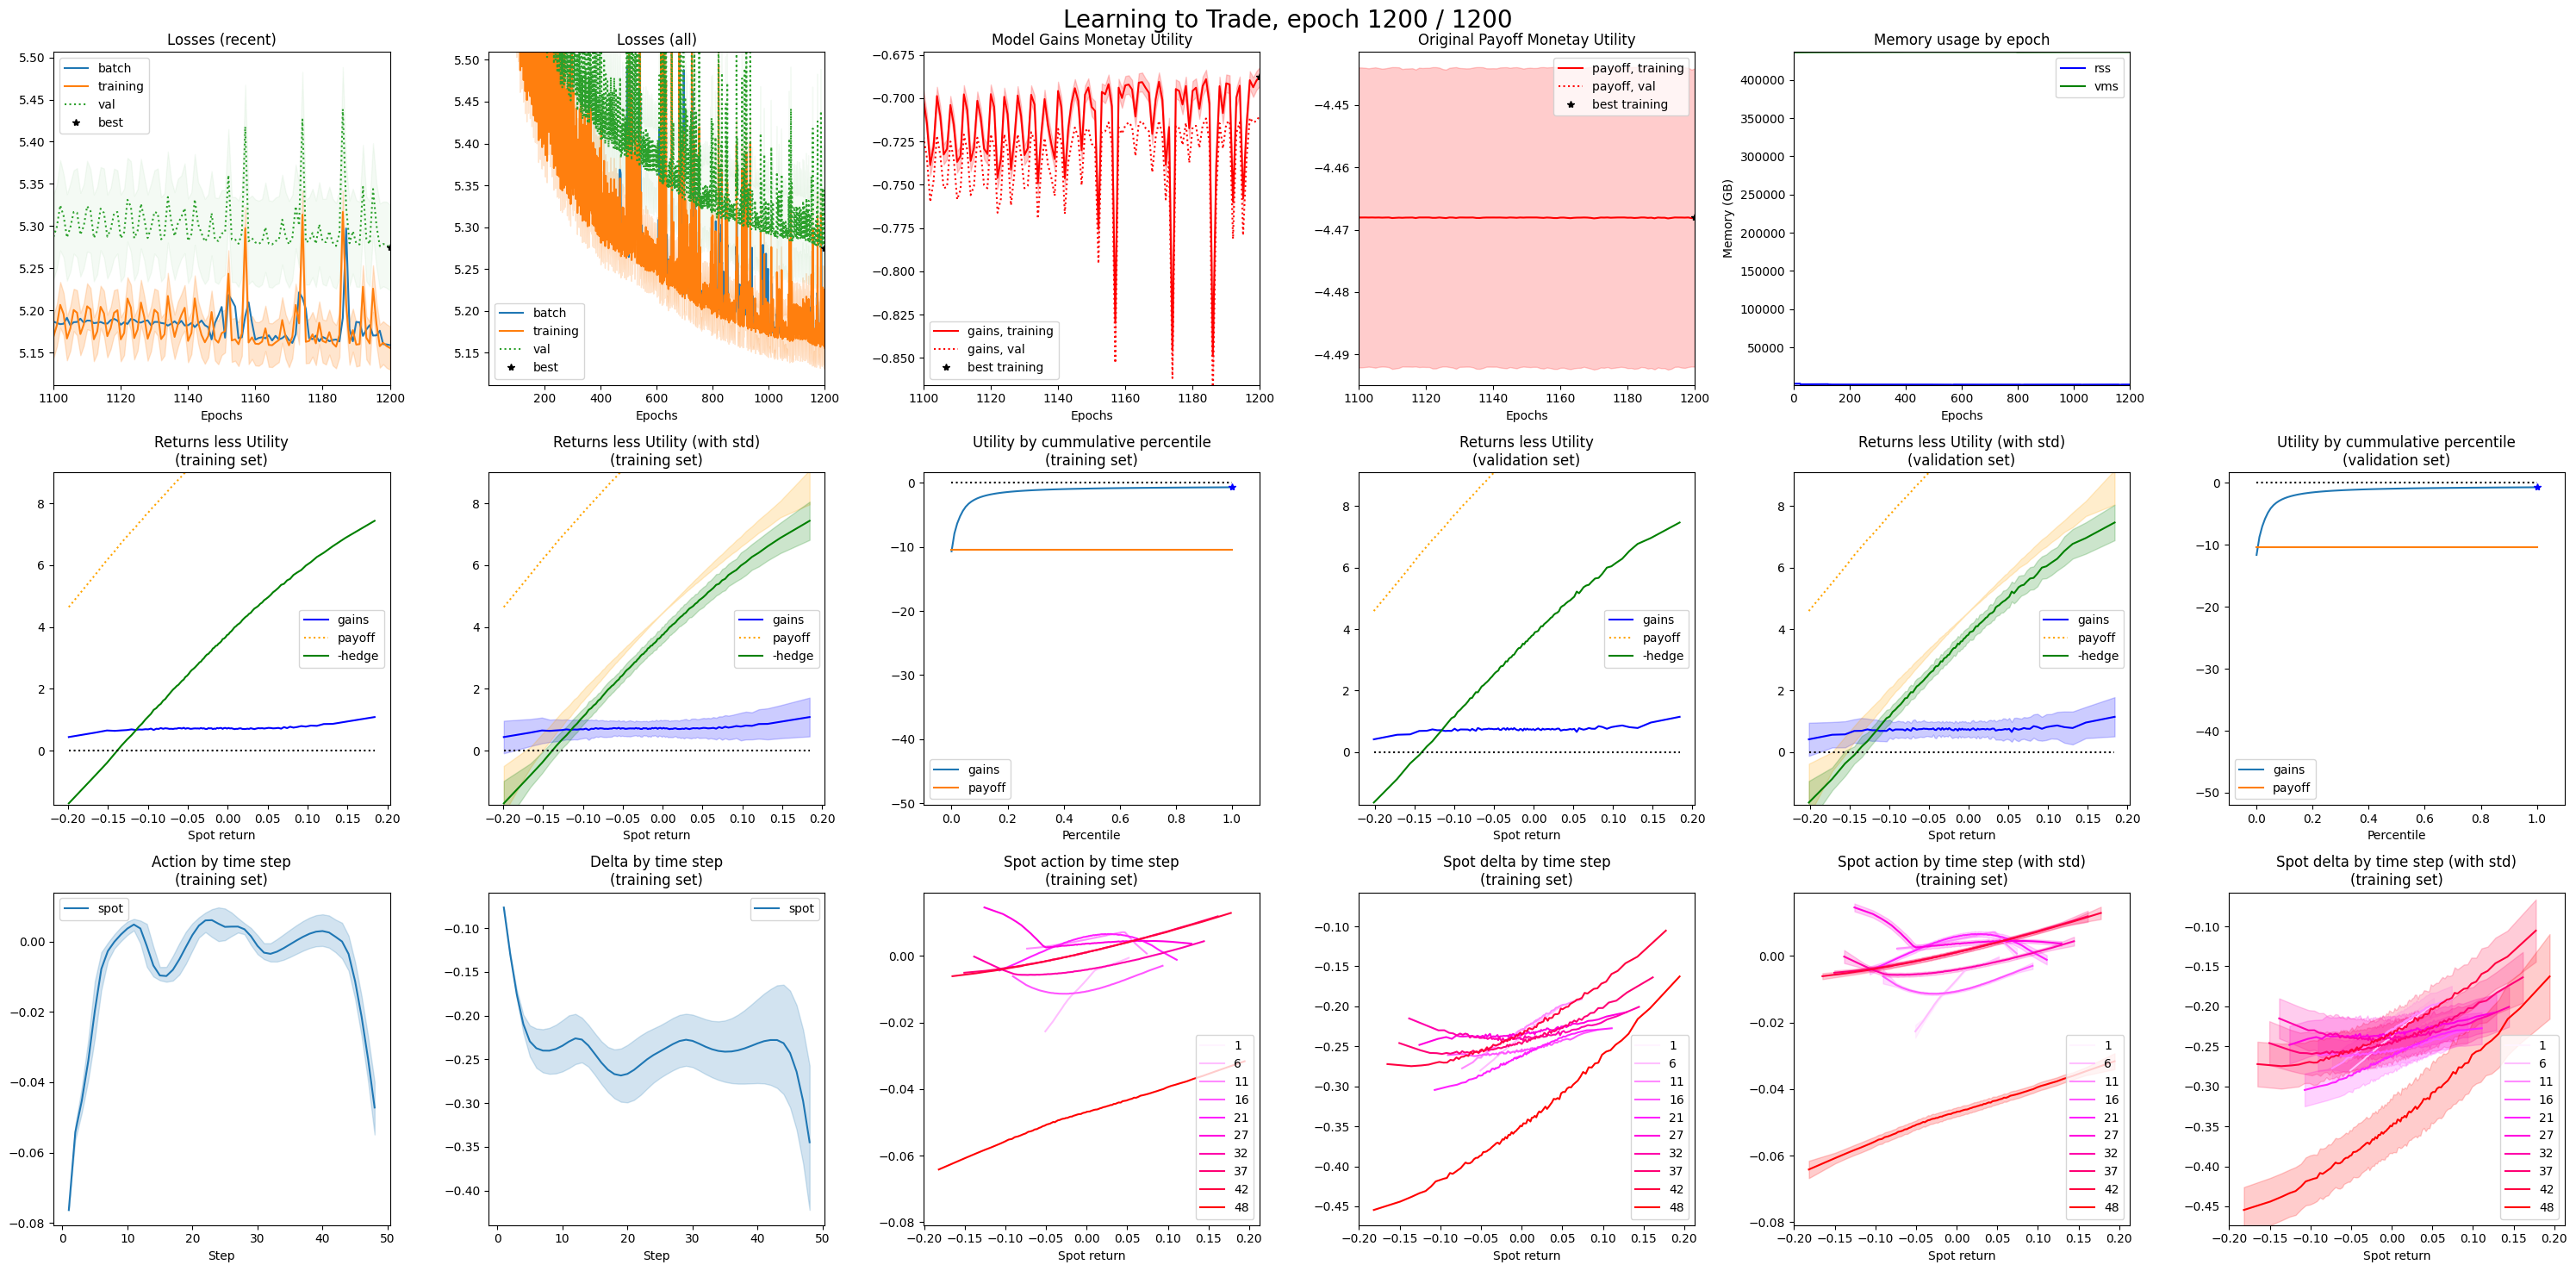

Training 1200/1200 epochs; 3378 weights; 50000 samples; 15000 validation samples batch size 4000 | initial loss 110.096 (1.63658), training 5.15555 (0.0257243), best 5.2746 (0.0508745), batch 5.15891, val 5.2746 (0.0508745); best epoch 1200 | memory used: rss 1260.16M, vms 436449M | time elapsed 51:13; time per epoch 2s; estimated time remaining 0s | current time: 2026-05-03 09:20:21                        2026-05-03 09:20:17                          
 Status: Training complete.
 Weights set to best validation epoch: 1200
 Time: 2026-05-03 09:20:23
Training terminated. Total time taken 51:18

Hedged:
    Mean:0.031649
    Std Dev: 0.316682
    Variance: 0.100287
    Skewness: -0.200763
    1% ES: -1.003945
    5% ES: -0.692836
    30% ES: -0.330069

Unhedged:
    Mean:-0.441760
    Std Dev: 1.847456
    Variance: 3.413093
    Skewness: -0.208887
    1% ES: -5.756518
    5% ES: -4.465802
    30% ES: -2.625008

Static Delta Hedge:
    Mean:-0.086251
    Std Dev: 0.180626
    Variance: 0.

In [ ]:
def compute_stats(gains, label):
    print(f"\n{label}:")
    print(f"    Mean:{np.mean(gains):.6f}")
    print(f"    Std Dev: {np.std(gains):.6f}")
    print(f"    Variance: {np.var(gains):.6f}")
    print(f"    Skewness: {skew(gains):.6f}")
    print(f"    1% ES: {np.mean(gains[gains <= np.percentile(gains,1)]):.6f}")
    print(f"    5% ES: {np.mean(gains[gains <= np.percentile(gains, 5)]):.6f}")
    print(f"    30% ES: {np.mean(gains[gains <= np.percentile(gains, 30)]):.6f}")

seeds = [2312414312]
# 333819, 44, 9992736, 7654321
models = ['C']


results = {model: {} for model in models}
eval_worlds = {model: {} for model in models}
static_results = {model: {} for model in models}

features = ['time_left', 'forward_price', 'wind_info']

#'B': 202604072
#'A': 202604071,
val_world_seeds = {'C': 202604073}
eval_world_seeds = {'C': 202604083}
val_samples = 15000
eval_samples = 40000
train_samples = 50000
train_epochs = 1600
use_transaction_cost = False

batch_size = 4000

steps_per_epoch = int(np.ceil(train_samples / batch_size))

total_steps = train_epochs * steps_per_epoch

for mod in models:
    config = Config()

    config.world.samples = train_samples
    config.world.steps = 48
    config.world.latent_model_type = 'synthetic' # world type: 'Replication', 'synthetic', 'era5field'
    config.world.feature_model_type = mod
    config.world.use_transaction_cost = use_transaction_cost
    config.world.l_max = 0.2680 # calibrated l_max=0.2680 -> 75th percentiel q_tilde

    config.gym.objective.utility = "cvar"
    config.gym.objective.lmbda = 19
    config.gym.agent.network.depth = 3
    config.gym.agent.network.activation = "selu"
    config.gym.agent.use_gru = False

    config.gym.agent.features = features
    config.gym.agent.state.features = features
    config.gym.agent.init_delta.features = features
    config.gym.objective.y.features = features

    # InverseTimeDecay: LR(t) = l0 / (1 + t / decay_steps).

    # With 50k samples and batch size 4000 there are 13 optimizer steps per epoch.

    # For 1200 epochs this gives about 15.6k optimizer steps in total.

    # A smaller decay_steps makes the late-epoch learning rate fall faster,

    # which reduces the repeated oscillation pattern you are seeing after convergence starts.

    lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
        initial_learning_rate=1e-4,
        decay_steps=1500,
        decay_rate=1.0,
        staircase=False,
    )
    config.trainer.train.early_stopping.patience = 120
    config.trainer.train.early_stopping.min_delta = 0.0
    config.trainer.train.optimizer.learning_rate = lr_schedule

    config.trainer.train.optimizer.name = "adam"
    config.trainer.train.optimizer.clipnorm = 1.0
    config.trainer.train.batch_size = batch_size
    config.trainer.train.epochs = train_epochs
    config.trainer.train.early_stopping.active = True

    config.trainer.train.early_stopping.start_epoch = 400
    config.trainer.train.tf_verbose = 0
    config.trainer.caching.mode = "off"
    config.trainer.output_level = 'all'
    config.trainer.visual.epoch_refresh = 10
    config.trainer.visual.confidence_pcnt_lo = 0.25
    config.trainer.visual.confidence_pcnt_hi = 0.75
    
    for idx, seed in enumerate(seeds):
        config.gym.tensorflow.seed = seed
        config.world.seed = seed

        train_world = PPAWorld(config.world)

        val_world = train_world.clone(seed=val_world_seeds[mod], samples=val_samples)

        eval_world = train_world.clone(seed=eval_world_seeds[mod], samples=eval_samples)

        optimal_static_delta = train_world.get_optimal_static_delta(
            lmbda=19.0
        )

        static_results[mod][idx] = {
            'optimal_delta': optimal_static_delta,
            'gains': eval_world.get_static_pnl(optimal_static_delta),
        }

        gym = VanillaDeepHedgingGym(config.gym)

        print(
            f"Starting training for model {mod}, seed {idx + 1}/{len(seeds)} "

            f"for {train_epochs} epochs with {steps_per_epoch} optimizer steps per epoch..."
        )

        train(gym=gym, world=train_world, val_world=val_world, config=Config(config.trainer))

        r_eval = gym(eval_world.tf_data)

        hedged_gains = r_eval['payoff'] + r_eval['pnl'] - r_eval['cost']

        unhedged_gains = r_eval['payoff']

        compute_stats(hedged_gains, "Hedged")

        compute_stats(unhedged_gains, "Unhedged")

        optimal_delta = eval_world.get_optimal_static_delta(lmbda=19.0)

        static_delta_gains = eval_world.get_static_pnl(optimal_delta)

        compute_stats(static_delta_gains, "Static Delta Hedge")

        results[mod][idx] = r_eval

        eval_worlds[mod][idx] = eval_world
        config.done()

        print(
            f"Out-of-sample results of model {mod} with seed {idx + 1} are stored in results, "
            f"with static delta {optimal_static_delta:.6f}."
        )


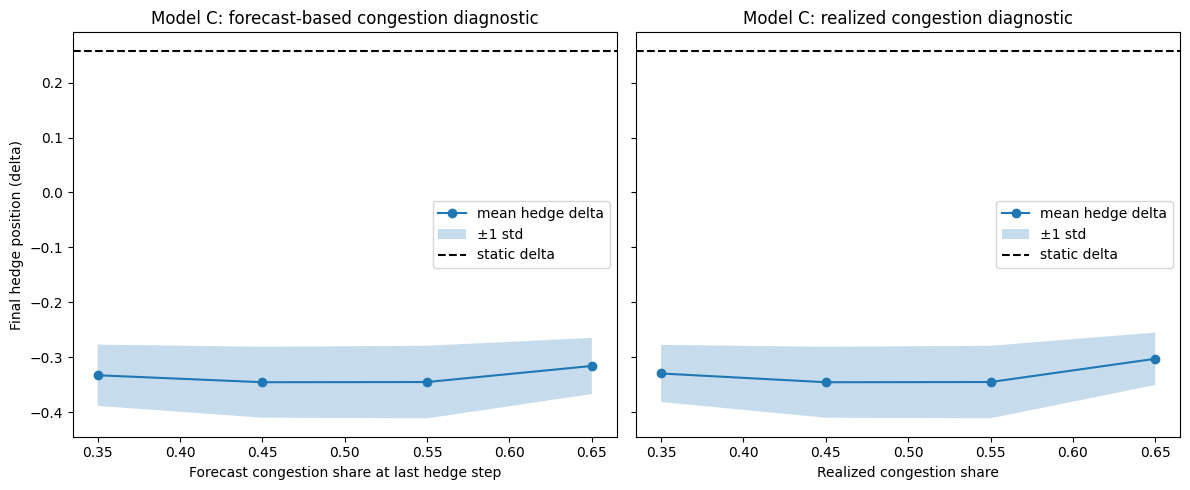

In [7]:
import numpy as np

import matplotlib.pyplot as plt



def infer_site_weights(eval_world):

    site_forecasts = np.asarray(eval_world.details.site_forecasts)

    q_agg_forecast = np.asarray(eval_world.details.q_agg_forecast)



    design = site_forecasts[:, :-1, :].reshape(-1, site_forecasts.shape[-1])

    target = q_agg_forecast[:, :-1].reshape(-1)

    weights, *_ = np.linalg.lstsq(design, target, rcond=None)

    weights = np.clip(weights, 0.0, None)

    weights_sum = weights.sum()

    if weights_sum <= 0.0:

        weights = np.ones(site_forecasts.shape[-1]) / site_forecasts.shape[-1]

    else:

        weights = weights / weights_sum

    return weights



def build_congestion_ratios(eval_world):

    site_forecasts = np.asarray(eval_world.details.site_forecasts)

    site_realized = np.asarray(eval_world.details.site_realized)

    site_weights = infer_site_weights(eval_world)

    split_idx = site_forecasts.shape[-1] // 2



    # Use the last forecast available before the terminal payoff is realized.

    forecast_last = site_forecasts[:, -2, :]

    forecast_mwh = forecast_last * site_weights

    q_cong_forecast = forecast_mwh[:, :split_idx].sum(axis=1)

    q_total_forecast = forecast_mwh.sum(axis=1)

    forecast_ratio = np.where(q_total_forecast > 1e-8, q_cong_forecast / q_total_forecast, 0.0)



    realized_mwh = site_realized * site_weights

    q_cong_realized = realized_mwh[:, :split_idx].sum(axis=1)

    q_total_realized = realized_mwh.sum(axis=1)

    realized_ratio = np.where(q_total_realized > 1e-8, q_cong_realized / q_total_realized, 0.0)

    return forecast_ratio, realized_ratio



def binned_mean_std(x, y, bins):

    bin_idx = np.clip(np.digitize(x, bins) - 1, 0, len(bins) - 2)

    mean_y = np.array([

        y[bin_idx == bin_no].mean() if np.any(bin_idx == bin_no) else np.nan

        for bin_no in range(len(bins) - 1)

    ])

    std_y = np.array([

        y[bin_idx == bin_no].std() if np.any(bin_idx == bin_no) else np.nan

        for bin_no in range(len(bins) - 1)

    ])

    return mean_y, std_y



bins = np.linspace(0, 1, 11)

bin_centers = 0.5 * (bins[:-1] + bins[1:])



fig, axes = plt.subplots(len(models), 2, figsize=(12, 5 * len(models)), sharey='row')

if len(models) == 1:

    axes = np.asarray([axes])



for row_idx, mod in enumerate(models):

    pooled_forecast_ratio = []

    pooled_realized_ratio = []

    pooled_final_delta = []

    static_deltas = []



    for seed_idx in sorted(results[mod].keys()):

        ew = eval_worlds[mod][seed_idx]

        result_seed = results[mod][seed_idx]



        forecast_ratio, realized_ratio = build_congestion_ratios(ew)

        actions = np.asarray(result_seed['actions'])

        final_delta = np.cumsum(actions, axis=1)[:, -1, 0]



        pooled_forecast_ratio.append(forecast_ratio)

        pooled_realized_ratio.append(realized_ratio)

        pooled_final_delta.append(final_delta)

        static_deltas.append(float(static_results[mod][seed_idx]['optimal_delta']))



    pooled_forecast_ratio = np.concatenate(pooled_forecast_ratio)

    pooled_realized_ratio = np.concatenate(pooled_realized_ratio)

    pooled_final_delta = np.concatenate(pooled_final_delta)

    static_delta_mean = float(np.mean(static_deltas))



    forecast_mean, forecast_std = binned_mean_std(pooled_forecast_ratio, pooled_final_delta, bins)

    realized_mean, realized_std = binned_mean_std(pooled_realized_ratio, pooled_final_delta, bins)



    ax_forecast = axes[row_idx, 0]

    ax_realized = axes[row_idx, 1]



    ax_forecast.plot(bin_centers, forecast_mean, marker='o', label='mean hedge delta')

    ax_forecast.fill_between(

        bin_centers,

        forecast_mean - forecast_std,

        forecast_mean + forecast_std,

        alpha=0.25,

        label='±1 std',

    )

    ax_forecast.axhline(static_delta_mean, color='black', linestyle='--', label='static delta')

    ax_forecast.set_xlabel('Forecast congestion share at last hedge step')

    ax_forecast.set_ylabel('Final hedge position (delta)')

    ax_forecast.set_title(f'Model {mod}: forecast-based congestion diagnostic')

    ax_forecast.legend()



    ax_realized.plot(bin_centers, realized_mean, marker='o', label='mean hedge delta')

    ax_realized.fill_between(

        bin_centers,

        realized_mean - realized_std,

        realized_mean + realized_std,

        alpha=0.25,

        label='±1 std',

    )

    ax_realized.axhline(static_delta_mean, color='black', linestyle='--', label='static delta')

    ax_realized.set_xlabel('Realized congestion share')

    ax_realized.set_title(f'Model {mod}: realized congestion diagnostic')

    ax_realized.legend()



plt.tight_layout()

plt.show()


In [ ]:
import pandas as pd



def expected_shortfall_np(values, alpha):

    values = np.asarray(values).reshape(-1)

    threshold = np.quantile(values, alpha)

    return float(np.mean(values[values <= threshold]))



calibration_world = PPAWorld(Config(config.world))

q_cong_calibration = np.asarray(calibration_world.details.q_cong)



sweep_calibration = pd.DataFrame(

    {

        'quantile': ['inf', 0.90, 0.80, 0.75, 0.70],

        'l_max': [np.inf] + [float(np.quantile(q_cong_calibration, q)) for q in (0.90, 0.80, 0.75, 0.70)],

    }

)

sweep_calibration['binding_frequency'] = [

    0.0 if not np.isfinite(l_max) else float(np.mean(q_cong_calibration > l_max))

    for l_max in sweep_calibration['l_max']

]

display(sweep_calibration)



def run_compact_lmax_sweep(

    lmax_values=None,

    sweep_models=('A', 'C'),

    sweep_seeds=None,

    sweep_train_epochs=None,

    sweep_val_samples=None,

    sweep_eval_samples=None,

):

    if lmax_values is None:

        lmax_values = sweep_calibration['l_max'].tolist()

    if sweep_seeds is None:

        sweep_seeds = list(seeds)

    if sweep_train_epochs is None:

        sweep_train_epochs = train_epochs

    if sweep_val_samples is None:

        sweep_val_samples = val_samples

    if sweep_eval_samples is None:

        sweep_eval_samples = eval_samples



    sweep_rows = []

    common_val_seed = 202604073

    common_eval_seed = 202604083



    for l_max_value in lmax_values:

        for mod in sweep_models:

            for seed in sweep_seeds:

                sweep_config = Config()

                sweep_config.world.samples = train_samples

                sweep_config.world.steps = 48

                sweep_config.world.latent_model_type = 'synthetic'

                sweep_config.world.feature_model_type = mod

                sweep_config.world.use_transaction_cost = use_transaction_cost

                sweep_config.world.l_max = float(l_max_value)

                sweep_config.world.seed = seed



                sweep_config.gym.objective.utility = 'cvar'

                sweep_config.gym.objective.lmbda = 19

                sweep_config.gym.agent.network.depth = 3

                sweep_config.gym.agent.network.activation = 'selu'

                sweep_config.gym.agent.use_gru = False

                sweep_config.gym.agent.features = features

                sweep_config.gym.agent.state.features = features

                sweep_config.gym.agent.init_delta.features = features

                sweep_config.gym.objective.y.features = features

                sweep_config.gym.tensorflow.seed = seed



                sweep_lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(

                    initial_learning_rate=1e-4,

                    decay_steps=1500,

                    decay_rate=1.0,

                    staircase=False,

                )

                sweep_config.trainer.train.optimizer.learning_rate = sweep_lr_schedule

                sweep_config.trainer.train.optimizer.name = 'adam'

                sweep_config.trainer.train.optimizer.clipnorm = 1.0

                sweep_config.trainer.train.batch_size = batch_size

                sweep_config.trainer.train.epochs = sweep_train_epochs

                sweep_config.trainer.train.early_stopping.active = True

                sweep_config.trainer.train.early_stopping.start_epoch = 400

                sweep_config.trainer.train.early_stopping.patience = 120

                sweep_config.trainer.train.early_stopping.min_delta = 0.0

                sweep_config.trainer.train.tf_verbose = 0

                sweep_config.trainer.caching.mode = 'off'

                sweep_config.trainer.output_level = 'all'

                sweep_config.trainer.visual.epoch_refresh = 10

                sweep_config.trainer.visual.confidence_pcnt_lo = 0.25

                sweep_config.trainer.visual.confidence_pcnt_hi = 0.75



                train_world = PPAWorld(sweep_config.world)

                val_world = train_world.clone(seed=common_val_seed, samples=sweep_val_samples)

                eval_world = train_world.clone(seed=common_eval_seed, samples=sweep_eval_samples)



                sweep_gym = VanillaDeepHedgingGym(sweep_config.gym)

                train(

                    gym=sweep_gym,

                    world=train_world,

                    val_world=val_world,

                    config=Config(sweep_config.trainer),

                )



                r_eval = sweep_gym(eval_world.tf_data)

                hedged = r_eval['payoff'] + r_eval['pnl'] - r_eval['cost']

                static_delta = eval_world.get_optimal_static_delta(lmbda=19.0)

                static_gains = eval_world.get_static_pnl(static_delta)



                sweep_rows.append(

                    {

                        'model': mod,

                        'seed': seed,

                        'l_max': float(l_max_value),

                        'binding_frequency': 0.0 if not np.isfinite(l_max_value) else float(np.mean(np.asarray(eval_world.details.q_cong) > l_max_value)),

                        'hedged_mean': float(np.mean(hedged)),

                        'hedged_es_1pct': expected_shortfall_np(hedged, 0.01),

                        'hedged_es_5pct': expected_shortfall_np(hedged, 0.05),

                        'static_mean': float(np.mean(static_gains)),

                        'static_es_1pct': expected_shortfall_np(static_gains, 0.01),

                        'static_es_5pct': expected_shortfall_np(static_gains, 0.05),

                    }

                )

                sweep_config.done()



    sweep_results = pd.DataFrame(sweep_rows)

    sweep_summary = (

        sweep_results

        .groupby(['model', 'l_max', 'binding_frequency'], as_index=False)

        .agg(

            hedged_mean=('hedged_mean', 'mean'),

            hedged_es_1pct=('hedged_es_1pct', 'mean'),

            hedged_es_5pct=('hedged_es_5pct', 'mean'),

            static_mean=('static_mean', 'mean'),

            static_es_1pct=('static_es_1pct', 'mean'),

            static_es_5pct=('static_es_5pct', 'mean'),

        )

    )

    sweep_summary['es_1pct_improvement_vs_static'] = sweep_summary['hedged_es_1pct'] - sweep_summary['static_es_1pct']

    sweep_summary['es_5pct_improvement_vs_static'] = sweep_summary['hedged_es_5pct'] - sweep_summary['static_es_5pct']

    display(sweep_summary.sort_values(['l_max', 'model']).reset_index(drop=True))

    return sweep_results, sweep_summary



#Example for a fast meeting-ready run:

sweep_results, sweep_summary = run_compact_lmax_sweep(

    lmax_values=sweep_calibration.loc[sweep_calibration['quantile'].isin([1.5, 0.75, 0.70]), 'l_max'],

    sweep_models=('A', 'C'),

    sweep_seeds=[2312414312],

    sweep_train_epochs=800,

)


,quantile,l_max,binding_frequency
0,inf,inf,0.00
1,0.9,0.280981,0.10
2,0.8,0.271311,0.20
3,0.75,0.267788,0.25
4,0.7,0.264591,0.30


OverflowError: cannot convert float infinity to integer

In [ ]:
from deephedging.objectives import oce_utility
from scipy.optimize import minimize_scalar

l_max = 0.2680 # same as training config

struct_cfg = Config()
struct_cfg.samples = 50000
struct_cfg.steps = 48
struct_cfg.latent_model_type = 'synthetic'
struct_cfg.feature_model_type = 'A' # irrelevant here; only paths matter
struct_cfg.l_max = l_max
struct_cfg.use_transaction_cost = False

struct_world = PPAWorld(struct_cfg)

q_cong_r = np.asarray(struct_world.details.q_cong) # pre-curtailment MWh, congested zone
q_total_r = np.asarray(struct_world.details.q_total_realized) # q_cong + q_unc (capacity factor)
q_tilde_r = np.asarray(struct_world.details.q_tilde) # delivered MWh after curtailment

congested = q_cong_r > l_max
uncongested = ~congested

print(f"Fraction of paths where congestion is active: {congested.mean():.3f}")
print(f" Congested paths: {congested.sum()}")
print(f" Uncongested paths: {uncongested.sum()}")

payoffs = np.asarray(struct_world.details.payoff)
price_chg = struct_world.details.forward_price[:, -1] - struct_world.details.forward_price[:, 0]

def opt_delta(mask):
    def obj(d):
        pnl = payoffs[mask] + d * (-price_chg[mask])
        return -oce_utility(utility='cvar', lmbda=19, X=pnl)
    return minimize_scalar(obj, bounds=(0, 1.5), method='bounded').x

delta_all = opt_delta(np.ones(len(payoffs), dtype=bool))
delta_cong = opt_delta(congested)
delta_uncong = opt_delta(uncongested)

print(f"\nOptimal static delta (all paths): {delta_all:.4f}")
print(f"Optimal static delta (congested paths): {delta_cong:.4f}")
print(f"Optimal static delta (uncongested paths): {delta_uncong:.4f}")
print(f"\nDifference (uncong - cong): {delta_uncong - delta_cong:.4f}")
print()
if abs(delta_uncong - delta_cong) > 0.02:
    print("=> Difference is meaningful: the congestion split is decision-relevant.")
    print(" Model C (which can forecast this split) can structurally outperform Model A.")
else:
    print("=> Difference is negligible: congestion split adds little hedging value.")



In [ ]:
import pandas as pd
from scipy.stats import skew


def expected_shortfall(gains, alpha):
    x = np.asarray(gains).reshape(-1)
    q_alpha = np.quantile(x, alpha)
    tail = x[x <= q_alpha]
    return float(np.mean(tail))


def summarize_gains_across_seeds(results, model_key, static_results=None):
    seed_indices = sorted(results[model_key].keys())
    positions = ["hedged", "unhedged"]
    if static_results is not None and model_key in static_results:
        positions.append("static_delta")

    per_seed_rows = []
    pooled_by_position = {position: [] for position in positions}

    for seed_idx in seed_indices:
        r_i = results[model_key][seed_idx]
        gains_by_position = {
            "hedged": r_i["payoff"] + r_i["pnl"] - r_i["cost"],
            "unhedged": r_i["payoff"],
        }
        if "static_delta" in pooled_by_position:
            gains_by_position["static_delta"] = static_results[model_key][seed_idx]["gains"]

        for position, gains in gains_by_position.items():
            gains_array = np.asarray(gains).reshape(-1)
            pooled_by_position[position].append(gains_array)
            per_seed_rows.append(
                {
                    "model": model_key,
                    "seed_run": seed_idx,
                    "position": position,
                    "mean": float(np.mean(gains_array)),
                    "variance": float(np.var(gains_array)),
                    "skewness": float(skew(gains_array)),
                    "es_1pct": expected_shortfall(gains_array, 0.01),
                    "es_5pct": expected_shortfall(gains_array, 0.05),
                }
            )

    per_seed_summary = pd.DataFrame(per_seed_rows)
    per_seed_summary = per_seed_summary[
        ["model", "seed_run", "position", "mean", "variance", "skewness", "es_1pct", "es_5pct"]
    ]
    per_seed_summary[["mean", "variance", "skewness", "es_1pct", "es_5pct"]] = (
        per_seed_summary[["mean", "variance", "skewness", "es_1pct", "es_5pct"]]
        .astype(float)
        .round(6)
    )

    summary_rows = []
    for position in positions:
        pooled = np.concatenate(pooled_by_position[position])
        subset = per_seed_summary[per_seed_summary["position"] == position]
        summary_rows.append(
            {
                "model": model_key,
                "position": position,
                "mean_avg_over_seeds": float(subset["mean"].mean()),
                "variance_avg_over_seeds": float(subset["variance"].mean()),
                "skewness_avg_over_seeds": float(subset["skewness"].mean()),
                "es_1pct_avg_over_seeds": float(subset["es_1pct"].mean()),
                "es_5pct_avg_over_seeds": float(subset["es_5pct"].mean()),
                "pooled_mean": float(np.mean(pooled)),
                "pooled_variance": float(np.var(pooled)),
                "pooled_skewness": float(skew(pooled)),
                "pooled_es_1pct": expected_shortfall(pooled, 0.01),
                "pooled_es_5pct": expected_shortfall(pooled, 0.05),
            }
        )

    summary = pd.DataFrame(summary_rows)
    summary = summary[
        [
            "model",
            "position",
            "mean_avg_over_seeds",
            "variance_avg_over_seeds",
            "skewness_avg_over_seeds",
            "es_1pct_avg_over_seeds",
            "es_5pct_avg_over_seeds",
            "pooled_mean",
            "pooled_variance",
            "pooled_skewness",
            "pooled_es_1pct",
            "pooled_es_5pct",
        ]
    ]
    numeric_cols = [
        "mean_avg_over_seeds",
        "variance_avg_over_seeds",
        "skewness_avg_over_seeds",
        "es_1pct_avg_over_seeds",
        "es_5pct_avg_over_seeds",
        "pooled_mean",
        "pooled_variance",
        "pooled_skewness",
        "pooled_es_1pct",
        "pooled_es_5pct",
    ]
    summary[numeric_cols] = summary[numeric_cols].astype(float).round(6)

    print(f"\nModel {model_key} per-seed gains summary")
    display(per_seed_summary)

    print(f"\nModel {model_key} aggregated gains summary")
    display(summary)

    return per_seed_summary, summary


all_per_seed_summaries = []
all_aggregated_summaries = []

for model_key in results.keys():
    per_seed_summary, aggregated_summary = summarize_gains_across_seeds(
        results,
        model_key,
        static_results=static_results,
    )
    all_per_seed_summaries.append(per_seed_summary)
    all_aggregated_summaries.append(aggregated_summary)

per_seed_validation_summary = pd.concat(all_per_seed_summaries, ignore_index=True)
validation_summary = pd.concat(all_aggregated_summaries, ignore_index=True)

validation_summary

In [ ]:
display(Markdown("## Deep Hedging in a PPA World"))
world = PPAWorld(config.world)
val_world = world.clone(samples=world.nSamples // 10)

gym = VanillaDeepHedgingGym(config.gym)
print(type(config.trainer))

train(gym=gym, world=world, val_world=val_world, config=Config(config.trainer))
r = gym(world.tf_data)

print("Keys of the dictionary returned by the gym: ", r.keys())

print("=========================================")
print("Config usage report")
print("=========================================")
print(config.usage_report())
config.done()

optimal_delta = world.get_optimal_static_delta(lmbda=19.0)
static_delta_gains = world.get_static_pnl(optimal_delta)
print(f"Optimal static delta: {optimal_delta:.6f}")

In [ ]:
print(f"Analysis of actions: {r['actions']}")

In [ ]:
import numpy as np
from scipy.stats import skew

print("Analysis of PnL used in PPA article:\n")
print(f"Mean payoff: {np.mean(r['payoff']):.6f}")
print(f"Min utility: {np.min(r['utility']):.6f}")
print(f"Min unhedged utility: {np.min(r['utility0']):.6f}")
print(f"Mean hedging pnl: {np.mean(r['pnl']):.6f}")  
print(f"Mean cost: {np.mean(r['cost']):.6f}")
print(f"Mean total gains: {np.mean(r['payoff'] + r['pnl'] - r['cost']):.6f}\n")


hedged_gains = r['payoff'] + r['pnl'] - r['cost']
unhedged_gains = r['payoff']

def compute_stats(gains, label):
    print(f"\n{label}:")
    print(f"    Mean:{np.mean(gains):.6f}")
    print(f"    Std Dev: {np.std(gains):.6f}")
    print(f"    Variance: {np.var(gains):.6f}")
    print(f"    Skewness: {skew(gains):.6f}")
    print(f"    1% ES: {np.mean(gains[gains <= np.percentile(gains,1)]):.6f}")
    print(f"    5% ES: {np.mean(gains[gains <= np.percentile(gains, 5)]):.6f}")
    print(f"    30% ES: {np.mean(gains[gains <= np.percentile(gains, 30)]):.6f}")

compute_stats(hedged_gains, "Hedged gains")
compute_stats(unhedged_gains, "Unhedged gains")
compute_stats(static_delta_gains, "static delta hedge")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert notebook outputs to numpy
actions = np.asarray(r["actions"])
hedged = np.asarray(hedged_gains).reshape(-1)
static_hedged = np.asarray(static_delta_gains).reshape(-1)

# Cumulative delta path; one hedge instrument in your PPA setup
deltas = np.cumsum(actions, axis=1)[:, :, 0]
final_delta = deltas[:, -1]

# Dynamic minus static pathwise gain
gap = hedged - static_hedged

print("Static benchmark")
print(f"optimal_delta: {optimal_delta:.6f}")

print("\nLearned hedge position")
print(f"mean final learned delta: {np.mean(final_delta):.6f}")
print(f"std final learned delta:  {np.std(final_delta):.6f}")
print(f"mean(final_delta - optimal_delta): {np.mean(final_delta - optimal_delta):.6f}")
print(f"median(final_delta - optimal_delta): {np.median(final_delta - optimal_delta):.6f}")

print("\nDynamic minus static gains: hedged_gains - static_delta_gains")
print(f"mean:   {np.mean(gap):.6f}")
print(f"median: {np.median(gap):.6f}")
print(f"std:    {np.std(gap):.6f}")
print(f"1% q:   {np.quantile(gap, 0.01):.6f}")
print(f"5% q:   {np.quantile(gap, 0.05):.6f}")
print(f"30% q:  {np.quantile(gap, 0.30):.6f}")
print(f"P(dynamic > static): {np.mean(gap > 0.0):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Mean learned delta path vs static delta
axes[0].plot(deltas.mean(axis=0), lw=2, label="mean learned delta")
axes[0].axhline(optimal_delta, color="black", linestyle="--", label=f"static delta = {optimal_delta:.4f}")
axes[0].set_title("Mean learned delta vs static")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Delta")
axes[0].legend()

# 2. Sample learned delta paths
n_plot = min(25, deltas.shape[0])
for i in range(n_plot):
    axes[1].plot(deltas[i], color="tab:blue", alpha=0.15)
axes[1].axhline(optimal_delta, color="black", linestyle="--", label="static delta")
axes[1].set_title("Sample learned delta paths")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Delta")
axes[1].legend()

# 3. Distribution of dynamic minus static gains
axes[2].hist(gap, bins=80, density=True, alpha=0.75, color="tab:green")
axes[2].axvline(0.0, color="black", linestyle=":")
axes[2].axvline(np.mean(gap), color="red", linestyle="--", label=f"mean = {np.mean(gap):.4f}")
axes[2].set_title("Distribution of dynamic - static gains")
axes[2].set_xlabel("hedged_gains - static_delta_gains")
axes[2].legend()

plt.tight_layout()
plt.show()

Analysis of PnL used in PPA article:

Mean payoff: -0.420818
Mean hedging pnl: 0.013757
Mean cost: 0.000000
Mean total gains: -0.407061


Hedged gains:
    Mean:-0.407061
    Std Dev: 0.461946
    Variance: 0.213394
    Skewness: -1.885671
    1% ES: -2.557579
    5% ES: -1.764448
    30% ES: -0.946074

Unhedged gains:
    Mean:-0.420818
    Std Dev: 4.919069
    Variance: 24.197241
    Skewness: -0.377313
    1% ES: -15.292539
    5% ES: -11.550355
    30% ES: -6.301272

Replication simulation WITH transaction costs. ES is slightly off and costs are the reasons for the mean being different

Mean payoff: -0.398965
Min utility: -110.988342
Min unhedged utility: -409.681549
Mean hedging pnl: 0.010662
Mean cost: 0.412432
Mean total gains: -0.800736


Hedged gains:
    Mean:-0.800736
    Std Dev: 0.531346
    Variance: 0.282329
    Skewness: -1.217105
    1% ES: -3.021334
    5% ES: -2.237650
    30% ES: -1.418635

Unhedged gains:
    Mean:-0.398965
    Std Dev: 5.019406
    Variance: 25.194437
    Skewness: -0.359211
    1% ES: -15.498129
    5% ES: -11.730863
    30% ES: -6.387095

Static delta hedge:
    Mean: -0.389030
    Std Dev: 0.591305
    Variance: 0.349641
    Skewness: -2.654209
    1% ES: -3.420745
    5% ES: -2.285734
    30% ES: -1.070804

### adjusted LR scheduler with 600 epochs

Hedged gains:
    Mean:-0.243869
    Std Dev: 0.647518
    Variance: 0.419280
    Skewness: 0.159944
    1% ES: -2.192536
    5% ES: -1.584835
    30% ES: -0.954978

Unhedged gains:
    Mean:-0.248784
    Std Dev: 4.031268
    Variance: 16.251123
    Skewness: -0.251968
    1% ES: -11.950885
    5% ES: -9.100263
    30% ES: -5.026410

static delta hedge:
    Mean:-0.241618
    Std Dev: 0.381467
    Variance: 0.145517
    Skewness: -2.691466
    1% ES: -2.229360
    5% ES: -1.464579
    30% ES: -0.678836

### Model C with 900 epochs -> stabilizes at 10.3 after approx 300 epochs, significantly lower ES

Mean payoff: -0.254755
Min utility: -42.962860
Min unhedged utility: -227.765854
Mean hedging pnl: 0.012628
Mean cost: 0.000000
Mean total gains: -0.242128


Hedged gains:
    Mean:-0.242128
    Std Dev: 0.373774
    Variance: 0.139707
    Skewness: -0.750042
    1% ES: -1.650790
    5% ES: -1.192677
    30% ES: -0.675390

Unhedged gains:
    Mean:-0.254755
    Std Dev: 4.011731
    Variance: 16.093988
    Skewness: -0.256438
    1% ES: -11.996571
    5% ES: -9.099676
    30% ES: -4.998244

static delta hedge:
    Mean:-0.239336
    Std Dev: 0.378801
    Variance: 0.143490
    Skewness: -2.689944
    1% ES: -2.219588
    5% ES: -1.456407
    30% ES: -0.672873

### Statistical arbitrage test

In [ ]:
test_config2 = Config(config.trainer)
test_config2.train.epochs = 200
test_config2.caching.mode = "off"

test_world_config = Config(config.world)
test_world2 = PPAWorld(test_world_config)

# CRITICAL: Set payoff to zero
test_world2.data.market.payoff[:] = 0.0

# Clear any cached TensorFlow data
if hasattr(test_world2, '_tf_data'):
    delattr(test_world2, '_tf_data')

# Get the tf_data and MANUALLY fix the payoff
tf_data_fixed = test_world2.tf_data
tf_data_fixed['market']['payoff'] = test_world2.data.market.payoff.copy()

# Verify the fix
print(f"Before training - Payoff mean: {np.mean(test_world2.data.market.payoff):.10f}")
print(f"Fixed TF dataset payoff mean: {np.mean(tf_data_fixed['market']['payoff']):.10f}")
print(f"TF dataset payoff is zero? {np.all(tf_data_fixed['market']['payoff'] == 0)}")

test_gym2 = VanillaDeepHedgingGym(config.gym)

# Create a modified world object that returns our fixed tf_data
class FixedWorld:
    def __init__(self, original_world, fixed_tf_data):
        self.original_world = original_world
        self.fixed_tf_data = fixed_tf_data
        self.nSamples = original_world.nSamples
        self.nSteps = original_world.nSteps
        self.sample_weights = original_world.sample_weights
        self.data = original_world.data
        self.details = original_world.details
    
    @property
    def tf_data(self):
        return self.fixed_tf_data
    
    def clone(self, samples):
        return self.original_world.clone(samples=samples)
    
    def __getattr__(self, name):
        # Fallback to original_world for any missing attributes
        return getattr(self.original_world, name)

fixed_world = FixedWorld(test_world2, tf_data_fixed)

# Train with the fixed world
train(gym=test_gym2, world=fixed_world, val_world=test_world2.clone(samples=10000), config=test_config2)

# Evaluate with the fixed data
r_test2 = test_gym2(tf_data_fixed)

print(f"\n After training - Result payoff mean: {np.mean(r_test2['payoff']):.10f}")
print(f"Mean PnL: {np.mean(r_test2['pnl']):.6f}")
print(f"Max |action|: {np.max(np.abs(r_test2['actions'])):.6f}")

In [ ]:
# Additional diagnostics after your existing code
from scipy import stats

print("\n" + "="*60)
print("STATISTICAL SIGNIFICANCE TEST")
print("="*60)

print(f"\n📊 Detailed PnL Statistics:")
print(f"Mean PnL: {np.mean(r_test2['pnl']):.6f}")
print(f"Std dev of PnL: {np.std(r_test2['pnl']):.6f}")
print(f"Mean absolute PnL: {np.mean(np.abs(r_test2['pnl'])):.6f}")
print(f"Median PnL: {np.median(r_test2['pnl']):.6f}")

# t-test for PnL = 0
t_stat, p_value = stats.ttest_1samp(r_test2['pnl'], 0)
print(f"\n🔬 t-test for H0: mean PnL = 0")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_value:.6f}")

if p_value < 0.01:
    print("   ⚠️  PnL is statistically significantly different from zero at 1% level")
    print("   This suggests potential statistical arbitrage")
else:
    print("   ✅  PnL is NOT statistically significantly different from zero")
    print("   This is likely just optimization noise - no arbitrage detected")

# Cost analysis
print(f"\n💰 Cost Statistics:")
print(f"Mean cost: {np.mean(r_test2['cost']):.6f}")
print(f"Mean total gain (payoff + pnl - cost): {np.mean(r_test2['payoff'] + r_test2['pnl'] - r_test2['cost']):.6f}")

# Action analysis
print(f"\n📈 Action Statistics:")
print(f"Mean action: {np.mean(r_test2['actions']):.6f}")
print(f"Std dev of actions: {np.std(r_test2['actions']):.6f}")
print(f"% of zero actions: {100 * np.mean(np.abs(r_test2['actions']) < 0.001):.2f}%")

### Original deep hedging code in this file

In [ ]:
print("Deep Hedging AI says hello ... ", end='')
from cdxbasics.config import Config
from deephedging.trainer import train
from deephedging.gym import VanillaDeepHedgingGym
from deephedging.world import SimpleWorld_Spot_ATM

from IPython.display import display, Markdown
from cdxbasics.config import Config
# Re-wrap the trainer config before passing it in

# see print of the config below for numerous options
config = Config()
# world
config.world.samples = 10000
config.world.steps = 20
config.world.black_scholes = True
# gym
config.gym.objective.utility = "cvar"
config.gym.objective.lmbda = 1.
config.gym.agent.network.depth = 3
config.gym.agent.network.activation = "softplus"
# In trainer.ipynb, add to your config
# trainer
config.trainer.train.optimizer.name = "adam"
#config.trainer.train.optimizer.learning_rate = 0.001
#config.trainer.train.optimizer.clipvalue = 1.
#config.trainer.train.optimizer.global_clipnorm = 1.
config.trainer.train.batch_size = None
config.trainer.train.epochs = 800
config.trainer.caching.mode = "on"
# config.trainer.run_eagerly = True
config.trainer.visual.epoch_refresh = 5
config.trainer.visual.confidence_pcnt_lo = 0.25
config.trainer.visual.confidence_pcnt_hi = 0.75

display(Markdown("## Deep Hedging in a Black \& Scholes World"))

# create world
world  = SimpleWorld_Spot_ATM( config.world )
val_world  = world.clone(samples=world.nSamples//10)

# create training environment
gym = VanillaDeepHedgingGym( config.gym )
print(type(config.trainer))
# create training environment

train( gym=gym, world=world, val_world=val_world, config=Config(config.trainer) )
r = gym(world.tf_data)
print("Keys of the dictionary returned by the gym: ", r.keys())

print("=========================================")
print("Config usage report")
print("=========================================")
print( config.usage_report() )
config.done()

#### Comparison to Black & Scholes

See also notebooks/blackscholes for other notebooks. Note that we use medium risk aversion, hence the hedge is not expected to match the risk-neutral hedge. See the sub directory <tt>blackscholes</tt> for experiments approximating the black & scholes solution

In [ ]:
import deephedging.plot_bs_hedge as plot_bs_hedge
plot_bs_hedge.plot_blackscholes( world, gym, config )

## Stochastic Vol
### Trading with two assets

In [ ]:
print("Deep Hedging AI says hello  ... ", end='')
from cdxbasics.config import Config
from deephedging.trainer import train
from deephedging.gym import VanillaDeepHedgingGym
from deephedging.world import SimpleWorld_Spot_ATM
import tensorflow as tf

from IPython.display import display, Markdown

# see print of the config below for numerous options
config = Config()
# world
config.world.samples = 10000
config.world.steps = 20
config.world.black_scholes = False
# gym
config.gym.objective.utility = "cvar"
config.gym.objective.lmbda = 1.
config.gym.agent.network.depth = 3
config.gym.agent.network.activation = "softplus"
# trainer
config.trainer.train.optimizer.name = "adam"
config.trainer.train.optimizer.learning_rate = 0.001
config.trainer.train.optimizer.clipvalue = 1.
config.trainer.train.optimizer.global_clipnorm = 1.
config.trainer.train.batch_size = None
config.trainer.train.epochs = 800
config.trainer.caching.mode = "on"
config.trainer.train.run_eagerly = None
config.trainer.visual.epoch_refresh = 5
config.trainer.visual.confidence_pcnt_lo = 0.25
config.trainer.visual.confidence_pcnt_hi = 0.75

display(Markdown("## Deep Hedging in a simple Stochastic Volatility World"))

# create world
world  = SimpleWorld_Spot_ATM( config.world )
val_world  = world.clone(samples=world.nSamples//10)

# create training environment
tf.debugging.enable_check_numerics()
gym = VanillaDeepHedgingGym( config.gym )

# create training environment
train( gym=gym, world=world, val_world=val_world, config=config.trainer )
r = gym(world.tf_data)
print("Keys of the dictionary returned by the gym: ", r.keys())

print("=========================================")
print("Config usage report")
print("=========================================")
print( config.usage_report() )
config.done()